## Area vs Price

Scatter plot saved as 'area_vs_price_scatter.png'.


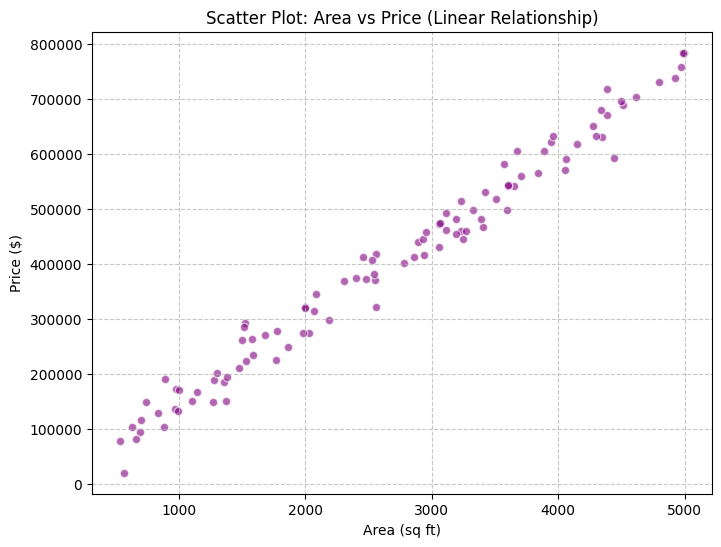

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Generate 100 random samples for Area (x) in square feet (e.g., 500 to 5000)
area_x = np.random.randint(500, 5000, 100)

# Create a linear relationship: Price = 150 * Area + noise
# Assuming an average price of $150 per sq ft
price_per_sqft = 150
noise = np.random.normal(0, 30000, 100)
price_y = (price_per_sqft * area_x) + noise

# Ensure prices are positive
price_y = np.maximum(price_y, 20000)

# Create the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(area_x, price_y, color='purple', alpha=0.6, edgecolors='w')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price ($)')
plt.title('Scatter Plot: Area vs Price (Linear Relationship)')
plt.grid(True, linestyle='--', alpha=0.7)

# Save the plot
plt.savefig('area_vs_price_scatter.png')
print("Scatter plot saved as 'area_vs_price_scatter.png'.")

# Linear Regresssion

In [8]:
import numpy as np
from sklearn.linear_model import LinearRegression

In [12]:
X = np.array([[1], [2], [4]]) # المدخلات
y = np.array([2, 4, 8])        # المخرجات

In [13]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


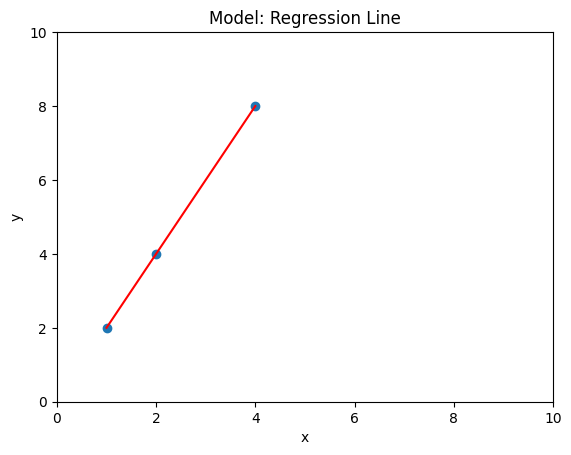

In [22]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.ylabel("y")
plt.xlabel("x")
plt.title("Model: Regression Line")
plt.show()

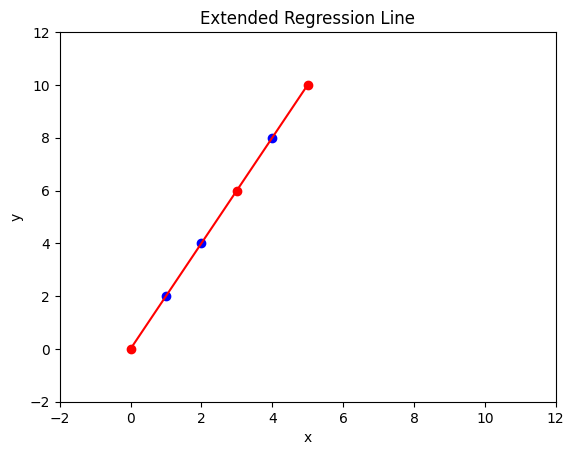

In [26]:
import matplotlib.pyplot as plt

X_new = np.array([[0], [3], [5]])
y_pred = model.predict(X_new)

plt.scatter(X, y, color='blue')
plt.scatter(X_new, y_pred, color='red')
plt.plot(X_new, y_pred, color='red')
plt.xlim(-2, 12)
plt.ylim(-2, 12)
plt.ylabel("y")
plt.xlabel("x")
plt.title("Extended Regression Line")
plt.show()

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generate simple linear data
# Source: numpy.random documentation for reproducibility
np.random.seed(42)
X = np.random.rand(20, 1) * 10  # Features
y = 2.5 * X + np.random.randn(20, 1) * 2  # Target with noise

print("Data Points (X, y):")
for xi, yi in zip(X[:5], y[:5]):
    print(f"X: {xi[0]:.2f}, y: {yi[0]:.2f}")

# 2. Split data into training and testing sets
# Source: sklearn.model_selection.train_test_split documentation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit the model
# Source: sklearn.linear_model.LinearRegression documentation
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make predictions
y_pred = model.predict(X_test)

# 5. Set evaluation criteria and score it
# Source: sklearn.metrics documentation (Mean Squared Error and R^2 Score)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
model_score = model.score(X_test, y_test)

print(f"\nEvaluation Metrics:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")
print(f"Model Score (Coefficient of Determination): {model_score:.2f}")

Data Points (X, y):
X: 3.75, y: 7.34
X: 9.51, y: 24.40
X: 7.32, y: 16.48
X: 5.99, y: 12.14
X: 1.56, y: 6.83

Evaluation Metrics:
Mean Squared Error: 6.06
R^2 Score: 0.87
Model Score (Coefficient of Determination): 0.87


# MAE vs MSE

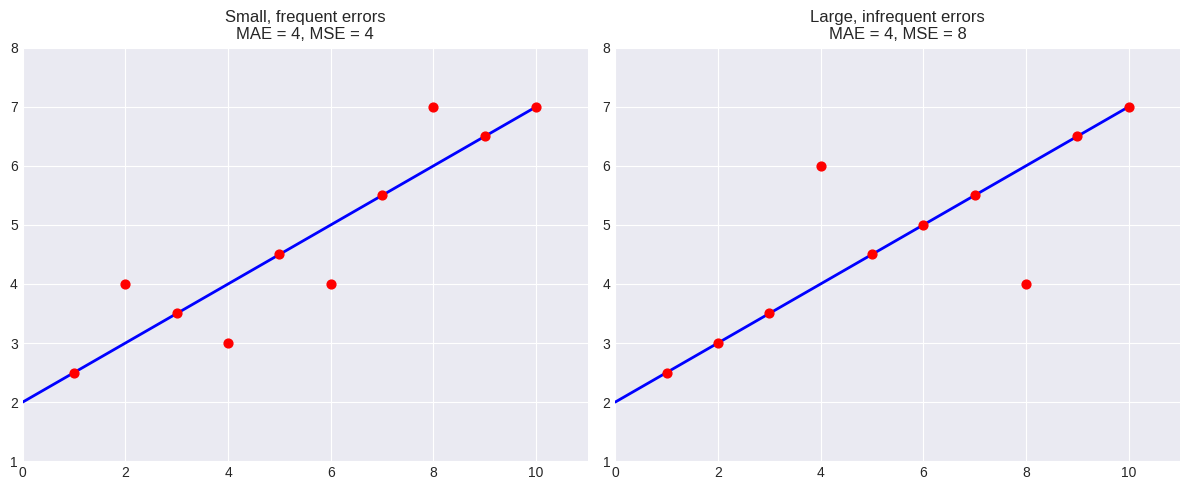

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Set the style
plt.style.use('seaborn-v0_8-darkgrid')

# Common regression line: y = 0.5x + 2
x_line = np.array([0, 10])
y_line = 0.5 * x_line + 2

# Left Plot Data
# MAE = 4, MSE = 4 over 10 points (total error)
# Points with error: (2, 4) err=1, (4, 3) err=-1, (6, 4) err=-1, (8, 7) err=1
# Others on line: (1, 2.5), (3, 3.5), (5, 4.5), (7, 5.5), (9, 6.5), (10, 7)
x_left = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_left = 0.5 * x_left + 2
y_left[1] += 1  # x=2, y=3+1=4
y_left[3] -= 1  # x=4, y=4-1=3
y_left[5] -= 1  # x=6, y=5-1=4
y_left[7] += 1  # x=8, y=6+1=7

# Right Plot Data
# MAE = 4, MSE = 8 over 10 points (total error)
# Points with error: (4, 6) err=2, (8, 4) err=-2
# Others on line: (1, 2.5), (2, 3), (3, 3.5), (5, 4.5), (6, 5), (7, 5.5), (9, 6.5), (10, 7)
x_right = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_right = 0.5 * x_right + 2
y_right[3] += 2  # x=4, y=4+2=6
y_right[7] -= 2  # x=8, y=6-2=4

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Left
ax1.plot(x_line, y_line, color='blue', linewidth=2)
ax1.scatter(x_left, y_left, color='red', s=40, zorder=3)
ax1.set_xlim(0, 11)
ax1.set_ylim(1, 8)
ax1.set_title("Small, frequent errors\nMAE = 4, MSE = 4")

# Plot Right
ax2.plot(x_line, y_line, color='blue', linewidth=2)
ax2.scatter(x_right, y_right, color='red', s=40, zorder=3)
ax2.set_xlim(0, 11)
ax2.set_ylim(1, 8)
ax2.set_title("Large, infrequent errors\nMAE = 4, MSE = 8")

plt.tight_layout()
plt.savefig('error_comparison.png')
plt.show()